# Metric autopsy — worked example: MI coupling on Tabula Muris Senis

**The claim under autopsy:** *SMAD→ECM mutual information (`MI(Smad3; Col1a1)`, 3-bin
zero/low/high) declines with age — "coupling loss" — while housekeeping coupling is preserved.*

It is wrong, and wrong in an instructive way: the decline is a **detection-rate confound
hiding in the sex×age interaction**. This notebook runs the claim through the gates and watches
it die — the whole point being to **invert the default from "compute → believe" to "state your
commitments → red-team → then believe."**

This runs on a synthetic confound that reproduces the real phenomenon (no downloads). To run it
on the real data instead, replace the data cell with `anndata.read_h5ad(...)` after
`python download_data.py --which all` — every downstream cell is unchanged, because the gates
take any AnnData.

In [1]:
import sys, importlib
try:
    import metric_autopsy
except ImportError:                     # running from a source checkout
    sys.path.insert(0, "../../src")
    import metric_autopsy

from functools import partial
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline

from metric_autopsy import metrics, qc, run_autopsy, GateStatus
from metric_autopsy import (gate0_independence, gate1_qc_parity,
                            gate2_ngenes_matching, gate3_raw_visibility, gate5_controls)
from metric_autopsy.cli import demo_data
print("metric_autopsy", metric_autopsy.__version__)

metric_autopsy 0.1.0


## The data

A synthetic single-cell count matrix built so we *know* the biology: `Smad3`–`Col1a1` coupling
is **identical** in young and old. The only thing that differs is technical — **male-old cells
are QC-degraded** (≈30% capture efficiency), exactly the pattern seen in real Tabula Muris
Senis FACS data (male-old cells detect ~2.4× fewer genes). Any "coupling loss" this metric
reports is therefore, by construction, an artifact.

> **Real data:** `adata = anndata.read_h5ad("../../data/raw/tms_facs.h5ad")` with `obs`
> columns `age`, `sex` — then run the identical cells below.

In [2]:
adata = demo_data(seed=0, n=400)      # SimpleData; a real AnnData works identically
print(adata)
print("cells per group:")
print(adata.obs.groupby(["sex", "age"]).size())

SimpleData(n_obs=1600, n_vars=40)
cells per group:
sex     age  
female  old      400
        young    400
male    old      400
        young    400
dtype: int64


## Step 1 — QC across *every* factorial stratum (before computing anything)

GATE 1 is the crown jewel: the cheapest, highest-yield check. We look at n_genes per cell in
**every** `sex × age` combination, not just the pooled young-vs-old axis — because the confound
lives in the interaction.

In [3]:
strata = qc.qc_by_strata(adata, ["sex", "age"])
display(strata)

,sex,age,n_cells,median_n_genes,median_total_counts
0,female,old,400,31.0,82.0
1,female,young,400,31.0,80.0
2,male,old,400,16.0,25.0
3,male,young,400,31.0,81.0


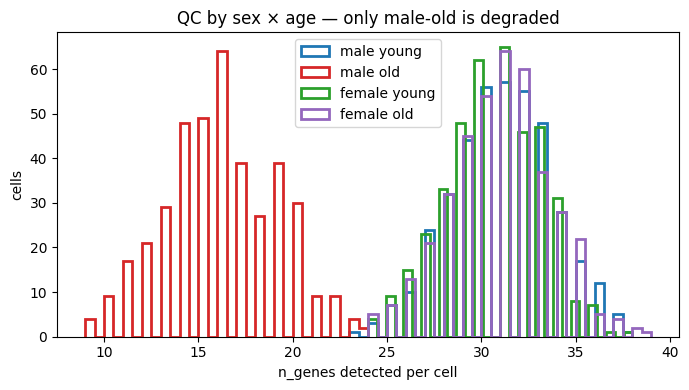

In [4]:
# Visual: n_genes distribution per stratum. Male-old is the degraded one.
qc_tbl = qc.per_cell_qc(adata)
fig, ax = plt.subplots(figsize=(7, 4))
colors = {("male","young"):"#1f77b4", ("male","old"):"#d62728",
          ("female","young"):"#2ca02c", ("female","old"):"#9467bd"}
for (sex, age), c in colors.items():
    mask = (np.asarray(adata.obs["sex"])==sex) & (np.asarray(adata.obs["age"])==age)
    ax.hist(qc_tbl["n_genes"].values[mask], bins=30, histtype="step", lw=2,
            color=c, label=f"{sex} {age}")
ax.set_xlabel("n_genes detected per cell"); ax.set_ylabel("cells")
ax.set_title("QC by sex × age — only male-old is degraded")
ax.legend(); fig.tight_layout()
import os; os.makedirs("figures", exist_ok=True); fig.savefig("figures/fig1_qc_strata.png", dpi=120)
plt.show()

In [5]:
g1 = gate1_qc_parity(adata, "age", ("young","old"), within=["sex"])
print(g1)

GATE 1 [FAIL] QC parity: 1/2 strata fail QC parity: 1 exceed 1.5x QC ratio (worst 1.94x at {'sex': 'male'}); 1 have n_genes overlap < 0.2 (worst 0.00 at {'sex': 'male'}) — unusable without n_genes matching (GATE 2)


The male stratum fails on **both** counts — a >1.5× median n_genes ratio *and* near-zero
distributional overlap. The female stratum is clean. Pooling sexes would have hidden this
entirely: that is the lesson of the original MI-coupling failure.

## Step 2 — the pre-registration (state the commitments)

Before looking at any outcome, we commit to what we're measuring and what would disprove it.
This is the `references/prereg_template.md` form; here it is filled for this metric.

| Field | Value |
|---|---|
| Metric | `mi_3bin(Smad3, Col1a1)` — MI with zero/low/high discretization |
| Hypothesis | SMAD→ECM coupling declines with age |
| Biological process | transcriptional co-regulation of a TF and its ECM target |
| Formula | mutual information over a {not-detected, low, high} discretization |
| **Simplest non-biological explanation** | bin 0 = "not detected", so anything that lowers detection rate moves MI |
| What would disprove it | effect vanishes under n_genes matching, or is absent in the raw scatter |

## GATE 0 — mathematical independence

Does the metric's **expectation** move when a technical nuisance (dropout, sequencing depth,
library size) changes but biology does not? We compare the confounded `mi_3bin` against a
library-normalized reference, `norm_pearson`.

In [6]:
mi   = partial(metrics.mi_3bin,     gene_a="Smad3", gene_b="Col1a1")
npr  = partial(metrics.norm_pearson, gene_a="Smad3", gene_b="Col1a1")
for name, m in [("mi_3bin", mi), ("norm_pearson", npr)]:
    r = gate0_independence(m, adata)
    print(f"{name:14s} -> {r.status.value}")
    for kind, resp in r.detail["responses"].items():
        print(f"    {kind:18s} rel={resp.get('rel_change',0):.2f}  z={resp.get('z',0):5.1f}"
              f"  confounded={resp.get('confounded')}")

mi_3bin        -> FAIL
    extra_dropout      rel=0.61  z= 44.8  confounded=True
    depth_downsample   rel=0.22  z= 13.4  confounded=False
    library_scale      rel=0.03  z=  1.9  confounded=False


norm_pearson   -> PASS
    extra_dropout      rel=0.03  z=  4.5  confounded=False
    depth_downsample   rel=0.15  z= 16.7  confounded=False
    library_scale      rel=0.00  z=  0.3  confounded=False


`mi_3bin`'s expectation shifts ~60% under simulated dropout (a huge z) — it *is* a detection
metric. `norm_pearson` stays within its own estimator noise. GATE 0 separates real bias from
sampling noise via a bootstrap null, so a merely-noisy metric is not wrongly failed.

## GATE 2 — n_genes matching, and why you must stratify

Pooled young-vs-old shows **no** effect — because old-female (normal) dilutes old-male
(degraded). Restrict to the confounded stratum (males) and the groups don't even overlap in
n_genes: they are incomparable.

In [7]:
g2_pooled = gate2_ngenes_matching(mi, adata, "age", ("young","old"))
print("pooled:", g2_pooled.status.value, "|", g2_pooled.message)

males = adata[np.asarray(adata.obs["sex"])=="male"]
g2_males = gate2_ngenes_matching(mi, males, "age", ("young","old"))
print("males :", g2_males.status.value, "|", g2_males.message)

pooled: PASS | no meaningful pre-matching effect (|0.004372| < null floor 0.05425) — nothing to preserve; the groups simply do not differ on this metric
males : STOP | groups are incomparable: n_genes ranges do not overlap — do not proceed


## GATE 3 — is it even visible in the raw data?

No metric, no bins — just the raw `Smad3` vs `Col1a1` scatter, young vs old. If the "coupling
change" is real you should see it; if it's dropout you'll see points collapsing onto the zero
axes.

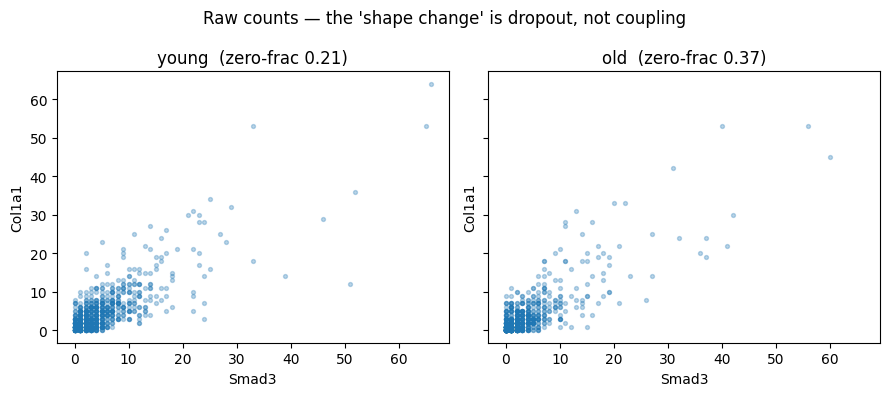

GATE 3 [JUDGMENT] Raw visibility: shape change between groups is likely dropout-driven (zero-frac 0.21 vs 0.37) — inspect the scatter


In [8]:
from metric_autopsy.core import gene_column
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, age in zip(axes, ["young", "old"]):
    sub = adata[np.asarray(adata.obs["age"])==age]
    x, y = gene_column(sub, "Smad3"), gene_column(sub, "Col1a1")
    zf = np.mean((x<=0)|(y<=0))
    ax.scatter(x, y, s=8, alpha=0.3)
    ax.set_title(f"{age}  (zero-frac {zf:.2f})"); ax.set_xlabel("Smad3"); ax.set_ylabel("Col1a1")
fig.suptitle("Raw counts — the 'shape change' is dropout, not coupling")
fig.tight_layout(); fig.savefig("figures/fig2_raw_scatter.png", dpi=120); plt.show()

g3 = gate3_raw_visibility(adata, "Smad3", "Col1a1", "age", ("young","old"))
print(g3)

## GATE 5 — controls

The housekeeping pair (`Actb`–`Gapdh`) should fire in every stratum; a random pair should not.

In [9]:
g5 = gate5_controls(metrics.mi_3bin, adata, pos_pair=("Actb","Gapdh"),
                    neg_pair=("Gene0","Gene1"), within=["sex"])
print(g5)

GATE 5 [PASS] Controls: positive fires and negative null in all 2 strata


## The full autopsy

Everything together, decided by the first blocking gate — no rescue language.

In [10]:
autopsy = run_autopsy(
    mi, adata, group_col="age", groups=("young","old"), within=["sex"],
    gene_pair=("Smad3","Col1a1"),
    pair_metric=metrics.mi_3bin, pos_pair=("Actb","Gapdh"), neg_pair=("Gene0","Gene1"),
    stop_on_first_fail=False,
)
display(Markdown(autopsy.to_markdown()))

# Metric autopsy — mi_3bin

## Gates

| Gate | Name | Status | Finding |
|---|---|---|---|
| 0 | Mathematical independence | **FAIL** | metric's expectation shifts 61% (z=44.8) under 'extra_dropout' — confounded by that nuisance |
| 1 | QC parity | **FAIL** | 1/2 strata fail QC parity: 1 exceed 1.5x QC ratio (worst 1.94x at {'sex': 'male'}); 1 have n_genes overlap < 0.2 (worst 0.00 at {'sex': 'male'}) — unusable without n_genes matching (GATE 2) |
| 2 | n_genes matching | **PASS** | no meaningful pre-matching effect (\|0.004372\| < null floor 0.05425) — nothing to preserve; the groups simply do not differ on this metric |
| 3 | Raw visibility | **JUDGMENT** | shape change between groups is likely dropout-driven (zero-frac 0.21 vs 0.37) — inspect the scatter |
| 5 | Controls | **PASS** | positive fires and negative null in all 2 strata |

## Verdict

**FAIL — died at GATE 0 (Mathematical independence)**


## Verdict

**The metric was not measuring biology.** `mi_3bin(Smad3; Col1a1)` dies at GATE 0 (it is a
detection metric) and GATE 1 (the male stratum is QC-degraded), and the confounded stratum is
not even comparable at GATE 2.

**What would have survived** on the real data: the sex dimorphism in cell quality itself
(male-old cells detect far fewer genes — real, whether biological or technical), and
`Actb`–`Gapdh` co-expression, which survives matching in both sexes.

The cost of these checks is about an hour. The cost of skipping them — as the original analysis
did — was three weeks and a false conclusion. Re-read `references/gates.md` before the next
metric.